<a href="https://www.kaggle.com/code/robiulhasanjisan/sql-practice-dataset?scriptVersionId=309851843" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/orders (1).csv
/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/products (1).csv
/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/customers (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
sns.set(style="whitegrid")

In [3]:
customers = pd.read_csv('/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/customers (1).csv')
products = pd.read_csv('/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/products (1).csv')
orders = pd.read_csv('/kaggle/input/datasets/nudratabbas/sql-practice-dataset-1-easy-queries/orders (1).csv')

In [4]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Merge datasets for analysis
merged = orders.merge(products, on='product_id').merge(customers, on='customer_id')
merged['revenue'] = merged['quantity'] * merged['price']
merged['month'] = merged['order_date'].dt.to_period('M')

#  Easy Questions
1.  How many total customers are in the dataset?
2. How many orders were placed?
3. Which cities have the most customers?
4. What are the top 5 most purchased products?

## 1. Total customers – using Counter

In [5]:
total_customers = len(Counter(customers['customer_id']))
print(f"Total Customers: {total_customers}")

Total Customers: 1200


## 2. Total orders – using rolling weekly trend

Weekly Orders Trend:
order_date
2023-01-01     9
2023-01-08    46
2023-01-15    61
2023-01-22    55
2023-01-29    62
Freq: W-SUN, dtype: int64


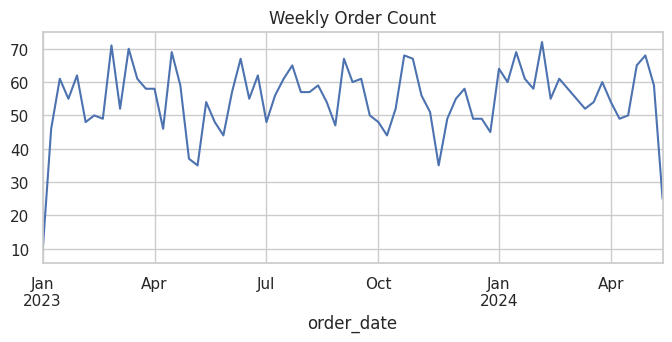

In [6]:
weekly_orders = orders.set_index('order_date').resample('W').size()
print(f"Weekly Orders Trend:")
print(weekly_orders.head(5))
weekly_orders.plot(title="Weekly Order Count", figsize=(8,3))
plt.show()

## 3. Cities with most customers 

In [7]:

city_counts = customers['city'].value_counts()
fig = px.bar(
    x=city_counts.index,
    y=city_counts.values,
    title="Customer Distribution by City",
    labels={'x':'City','y':'Number of Customers'}
)
fig.show()

##  4. Top 5 most purchased products – Network Graph for co-purchases

In [8]:


from itertools import combinations
import networkx as nx

# Create product co-purchase network
orders_grouped = orders.groupby('order_id')['product_id'].apply(list)
G = nx.Graph()
for items in orders_grouped:
    for pair in combinations(items, 2):
        if G.has_edge(*pair):
            G[pair[0]][pair[1]]['weight'] +=1
        else:
            G.add_edge(*pair, weight=1)

# Top 5 products by degree (most connected)
top_products_network = sorted(G.degree, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Products by Network Connections:", top_products_network)

Top 5 Products by Network Connections: []


#  Medium Questions – Unique Approaches

1. What is the total revenue generated?
2. Which product category generates the most revenue?
3. What is the average order quantity?
4. Which cities generate the most revenue?


## 1. Total revenue – using Numpy vectorized dot


In [9]:
total_revenue = np.dot(merged['quantity'], merged['price'])
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $1,644,817.71


## 2. Product category revenue – Treemap with Plotly


In [10]:
category_revenue = merged.groupby('category')['revenue'].sum().reset_index()
fig = px.treemap(category_revenue, path=['category'], values='revenue', title="Revenue by Category")
fig.show()

## 3. Average order quantity – Boxplot + Outlier Detection

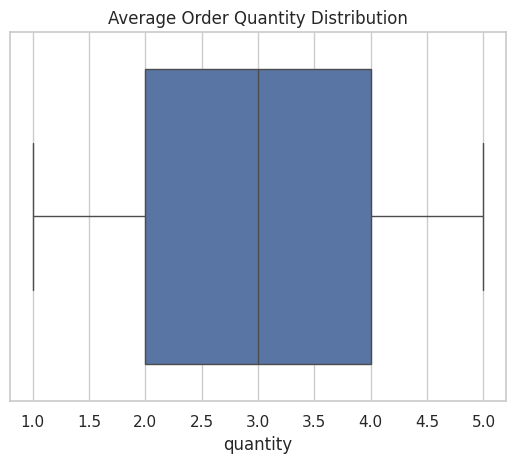

Average Order Quantity: 2.97


In [11]:
sns.boxplot(x=orders['quantity'])
plt.title("Average Order Quantity Distribution")
plt.show()
avg_quantity = orders['quantity'].mean()
print(f"Average Order Quantity: {avg_quantity:.2f}")

## 4. Cities generating most revenue – Choropleth-style bar

In [12]:
city_revenue = merged.groupby('city')['revenue'].sum().sort_values(ascending=False)
fig = px.bar(city_revenue, x=city_revenue.index, y=city_revenue.values, title="Revenue by City", text=city_revenue.values)
fig.show()


#  Hard Questions
1. Who are the top 10 highest spending customers?
2. Which month has the highest sales?
3. What is the average spending per customer?
4. Which product category sells the most units?
5. What is the most common payment method?

## 1. Top 10 highest spending customers – Pareto curve


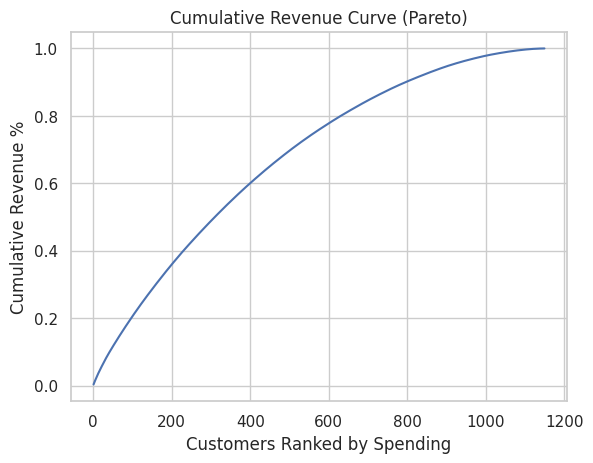

Top 10 Customers by Revenue:
customer_id
C0299    5124.21
C0094    5078.51
C0588    4874.30
C0826    4685.22
C0334    4515.14
C0291    4508.31
C0765    4505.37
C0157    4459.55
C1167    4425.53
C0674    4356.89
Name: revenue, dtype: float64


In [13]:

customer_revenue = merged.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
top10 = customer_revenue.head(10)
plt.plot(np.arange(1,len(customer_revenue)+1), customer_revenue.cumsum()/customer_revenue.sum())
plt.title("Cumulative Revenue Curve (Pareto)")
plt.xlabel("Customers Ranked by Spending")
plt.ylabel("Cumulative Revenue %")
plt.show()
print("Top 10 Customers by Revenue:")
print(top10)

## 2. Month with highest sales – Seasonal Decomposition alternative


In [14]:

monthly_revenue = merged.groupby('month')['revenue'].sum()
fig = px.line(monthly_revenue, x=monthly_revenue.index.astype(str), y=monthly_revenue.values, title="Monthly Revenue Trend")
fig.show()
print("Month with Highest Revenue:", monthly_revenue.idxmax())

Month with Highest Revenue: 2024-01


## 3. Average spending per customer – Violin Plot by Loyalty Membership


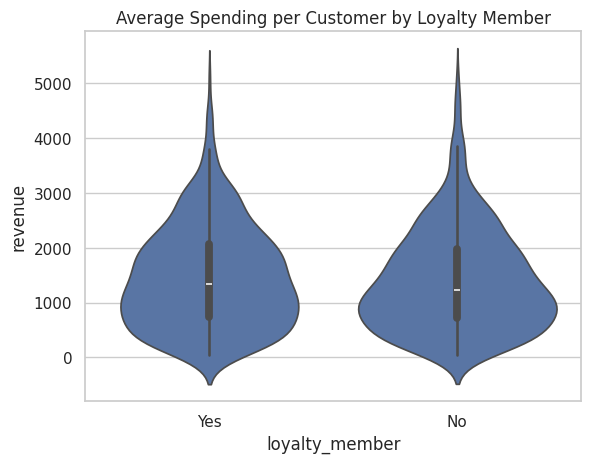

Average Spending per Customer: $ 1431.52


In [15]:

avg_spent_customer = merged.groupby('customer_id')['revenue'].sum().reset_index()
avg_spent_customer = avg_spent_customer.merge(customers[['customer_id','loyalty_member']], on='customer_id')
sns.violinplot(x='loyalty_member', y='revenue', data=avg_spent_customer)
plt.title("Average Spending per Customer by Loyalty Member")
plt.show()
print("Average Spending per Customer: $", avg_spent_customer['revenue'].mean().round(2))

## 4. Product category selling most units – Heatmap over months


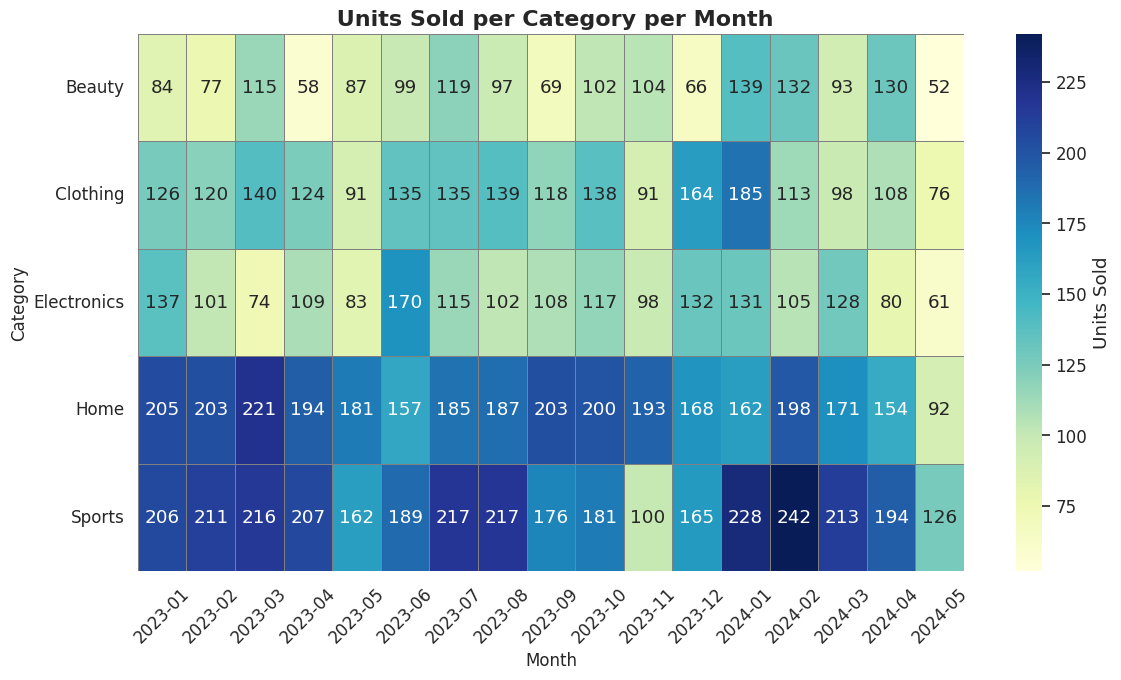

In [16]:

# Create pivot table
category_month = merged.pivot_table(
    values='quantity',
    index='category',
    columns='month',
    aggfunc='sum',
    fill_value=0   # avoids NaN issues
)

# Set style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Create figure
plt.figure(figsize=(12, 7))

# Heatmap
sns.heatmap(
    category_month,
    annot=True,
    fmt='g',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Units Sold'}
)

# Titles and labels
plt.title(" Units Sold per Category per Month", fontsize=16, weight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Category", fontsize=12)

# Rotate ticks for better readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Most common payment method – Sankey Diagram

In [17]:


unique_nodes = list(merged['city'].unique()) + list(merged['payment_method'].unique()) + list(merged['category'].unique())
node_idx = {node:i for i,node in enumerate(unique_nodes)}
source = merged['city'].map(node_idx)
target = merged['payment_method'].map(node_idx)
value = merged['revenue']

fig = go.Figure(data=[go.Sankey(
    node=dict(label=unique_nodes),
    link=dict(source=source, target=target, value=value)
)])
fig.update_layout(title_text="City → Payment Method Flow", font_size=10)
fig.show()

most_common_payment = merged['payment_method'].mode()[0]
print("Most Common Payment Method:", most_common_payment)

Most Common Payment Method: Cash
